This Notebook simulates automatic discretization of differential equations in an autodifferentiation compatible framework 'diffrax'.

Copyright 2023 HAMK Häme University of Applied Sciences. Licensed under CC0 / released in public domain.

Author: Olli Niemitalo (Olli.Niemitalo@hamk.fi)

Prey-predator cycle model was autogenerated using ChatGPT.

In [ ]:
!pip install diffrax

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


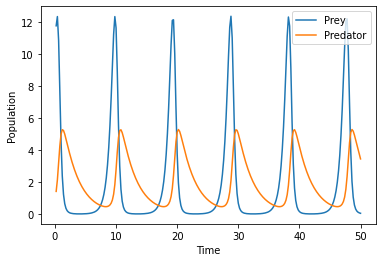

In [ ]:
from diffrax import diffeqsolve, Dopri5, ODETerm, SaveAt
import jax.numpy as jnp
from matplotlib import pyplot as plt

# Prey-predator dynamics model
# ----------------------------

# Set up the model parameters
prey_growth_rate = 1.0 # prey growth rate
predator_kill_rate = 0.5 # predator kill rate
predator_growth_rate = 0.2 # predator growth rate
predator_death_rate = 0.1 # predator death rate

# Model ODE
def prey_predator_ode(t, state, args):
  prey, predator = state
  dprey_dt = prey_growth_rate * prey - predator_kill_rate * prey * predator
  dpred_dt = predator_death_rate * prey * predator - predator_growth_rate * predator
  return [dprey_dt, dpred_dt]

# Prey immigration model
# ----------------------

# Set up the model parameters
prey_immigration_rate = 0.5 # prey immigration rate

# Model ODE
def prey_immigration_ode(t, state, args):
  prey, predator = state
  dprey_dt = prey_growth_rate;
  dpred_dt = 0;
  return [dprey_dt, dpred_dt]

# Composite model
# ---------------

def composite_ode(t, state, args):
  prey_predator = prey_predator_ode(t, state, args)
  prey_immigration = prey_predator_ode(t, state, args)
  return [prey_predator[0] + prey_immigration[0], prey_predator[1] + prey_immigration[1]]

# Simulation
# ----------

# Set up the simulation parameters
tmax = 50.0 # maximum simulation time
dt = 0.2 # time step size
init_state = [10.0, 1.0] # initial conditions
term = ODETerm(composite_ode) # Differential equation to solve
solver = Dopri5() # Solver
saveat = SaveAt(steps=True) # Save every simulation step

sol = diffeqsolve(term, solver, t0=0, t1=tmax, dt0=dt, y0=init_state, saveat=saveat)

# Plot the results
plt.plot(sol.ts, sol.ys[0], label='Prey')
plt.plot(sol.ts, sol.ys[1], label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()